In [1]:
from transformers import GPT2LMHeadModel

c:\Users\rohan\OneDrive\Desktop\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M - add "-xl" for 1.5B
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

c:\Users\rohan\OneDrive\Desktop\ML\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rohan\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 24961.08it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [10]:
sd_hf["transformer.wpe.weight"].view(-1)[:20] # positional embeddings

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

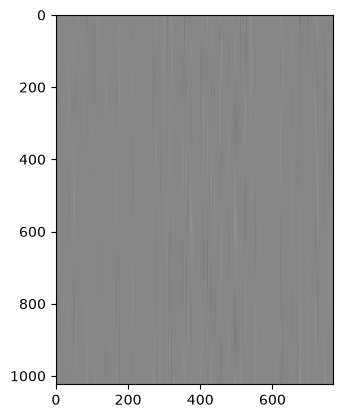

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline
# Plot the positional embeddings
plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")

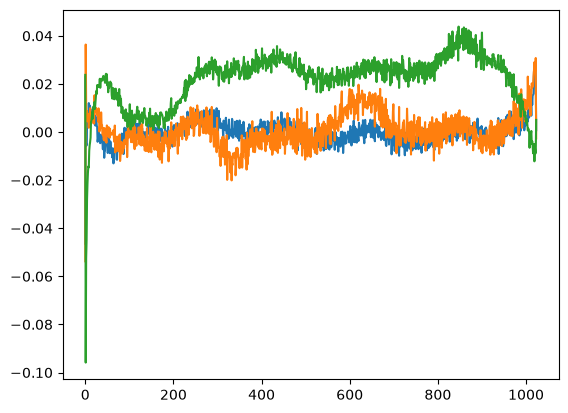

In [12]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

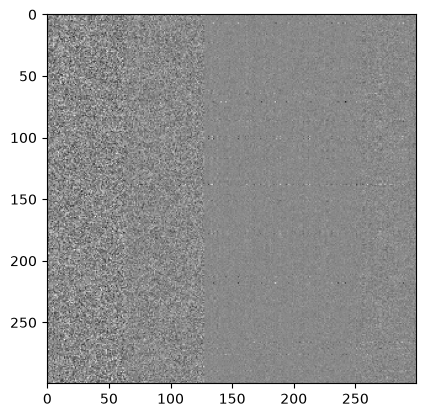

In [13]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300], cmap="gray")

In [14]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7157.85it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outpu

[{'generated_text': "Hello, I'm a language model, I'm a language model. In my mind, I'm doing the same thing as you. All these different people are thinking about the same thing.\n\nI'm not talking about what the computer program does. I'm talking about what I'm thinking about. I'm thinking about what my body is thinking about. I'm thinking about what I'm making it. I'm thinking about what I'm making it. What my body is doing. I'm thinking about what my body is thinking about. What's my body doing? What's my body doing? What's my body doing?\n\nLet's talk about this, I'm not a computer programmer. I'm not a software developer. I'm not a computer programmer. I'm not a language model. I'm not a language model. My body is thinking about what I'm doing. What is my body doing? What's my body doing? What's my body doing?\n\nNow, I'm not saying that this is a good thing. But if you want to get better at programming, you can get better at writing. You can get better at being human. You can get

In [2]:
# Replicating the code from train_gpt2_addforward_generate.py to generate text using the model directly
import torch
from torch.nn import functional as F
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
model.eval()
# model.to('cuda') # uncomment this to run on GPU, if available
torch.manual_seed(42)
# torch.cuda.manual_seed(42) # uncomment this to run on GPU, if available
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens # (5, 8)

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

c:\Users\rohankjain\Desktop\LLM Training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 20058.71it/s]


> Hello, I'm a language model, not a science. I'm a language designer. I want to write, I want to think. I want
> Hello, I'm a language model, I use an English sentence structure, I like words over sentences.

"That's OK I'll look
> Hello, I'm a language model, not just another language." This isn't a "language model?" It's an idea. So far, what
> Hello, I'm a language model, not a programming model. I'm not a theoretical computer model - you read that right - because my ideas are
> Hello, I'm a language model, I teach myself.

I want to know more about how languages work and why they could be used.


In [15]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [16]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [3]:
import torch
buf = torch.tensor(tokens[:24 + 1]) # +1 because we need ground truth for the last token
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[15496,    11,   314,  1101,   257,  3303],
        [ 2746,    11,   314,  4545,  3589,    13],
        [  198,   198,    40,   765,   284,   760],
        [  517,   546,   703,  8950,   670,   290]])
tensor([[  11,  314, 1101,  257, 3303, 2746],
        [  11,  314, 4545, 3589,   13,  198],
        [ 198,   40,  765,  284,  760,  517],
        [ 546,  703, 8950,  670,  290, 1521]])


In [18]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [19]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [20]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

2982199603155
2982199603155


In [5]:
# standard deviation grows inside the residual stream
import torch
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += n**-0.5 * torch.randn(768)
    # x += torch.randn(768)

print(x.std())

tensor(1.0148)


In [ ]:
# Each residual stream is of the form where we continue adding to it(Block defination during forward)
# So variance of activations in residual stream grows.
# The scaling factor of n**-0.5 exactly compensates for this growth where n is the
# number of layers in the model.
# This is the way to control the growth inside the residual stream during forward pass of the model.

In [ ]:
# By default in pytorch when we create tensors(activations, weights) - Its in float32 format.
# For deep learning models, this is quite a bit of memory and it can handle significantly lower precision.
# NVIDIA A100 - FP64 9.7 TFLOPS(not needed), FP32 19.5 TFLOPS(Trillion floating point operations per second).
# INT8 - used for inference not training, 624 TFLOPS - has uniform spacing, using floats gives us better 
# match for normal distribution of activations and weights. So we use FP16 or BF16 for training.
# GPU Memory - represents finite capacity of number of bits that our GPU can store
# GPU Memory Bandwidth - Speed with which we can access this memory
# Many of deep learning workloads for training are memory bound - tensor cores that do fast multiplications
# most of the time are waiting around(they are idle) because we can't feed them with data fast enough.
# If your utilization is around 60%, you are doing extremely well.
# If we come down in precision, we can store more data in the same memory and we can access it faster

In [ ]:
# Tensor core - Intruction in A100 architecture, does 4x4 matrix multiply
# Most computational work happens in Linear layers, which are matrix multiplies
# In 124M model, biggest matrix multiply is classifier layer at top which goes from 768 to 50257 which are
# accelerated with tensor cores.
# FP32 has 32 bits - 1 sign bit, 8 exponent bits, 23 mantissa bits
# TF32 has 19 bits - 1 sign bit, 8 exponent bits, 10 mantissa bits
# Only the mantissa bits get cropped, none of it is visible to pytorch and this enables it to calculate
# matrix multiplication 8x faster(19.5 TFLOPS vs 156 TFLOPS). This is the default for pytorch on A100.
# Speed up comes at the cost that we are reducing precision.
# In practise, enabling TF32 might now increase perform as much as 8x because -
# Workloads are memory bound, so even though multiplications are faster, a lot of float 32 data is being
# moved around and that is the bottleneck. So we are not able to feed tensor cores fast enough.

In [ ]:
# BF16 - 16 bits - 1 sign bit, 8 exponent bits, 7 mantissa bits
# It crops out mantissa bits even more than TF32. Exponent sets the range that you can represent and mantissa
# represents the precision. So BF16 has same range as FP32 but less precision.

# FP16 - 16 bits - 1 sign bit, 5 exponent bits, 10 mantissa bits
# It cannot represent a full range of FP32, so you need gradient scaling to avoid underflow.
# FP16 came first, was available in volta series GPUs before ampere.

# Using BF16 we are not just impacting numbers locally.
# Automatic Mixed Precision - https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html
# Only look at torch.autocast() - Do not call BF16 on any tensors, just call autocast
# Only surround forward pass of the model and loss calculation with autocast
# Leave the backward pass and optimizer step outside of autocast.
# What autocast actually converts -
# 1. Only matrix multiply like operations are converted to BF16
# 2. log_softmax, softmax, layer_norm like are kept in FP32 because they are sensitive to precision

In [ ]:
# torch.compile()
# Its basically a compiler for neural networks.
# It will cost you compilation time but it will speed up your training and inference.
# Speed up mainly comes from reducing Python overheads and GPU read/writes.


# about 2-3 times faster for training and inference.
# When we pass model to torch.compile(), it analyse the entire nn module and look at what operations we
# like to use and with benefit of knowing the exactly we want to do, it doesn't have to run on eager mode.
# Python interpreter will go layer by layer and operation by operation.
# Compiler sees the entire code at same time and optimizes that process.

# Constant reads and writes to GPU memory is a bottleneck for training and inference. 
# Interpreter will do these round trips to GPU memory for every operation. Compiler can see the entire 
# graph and it can reduce these round trips.

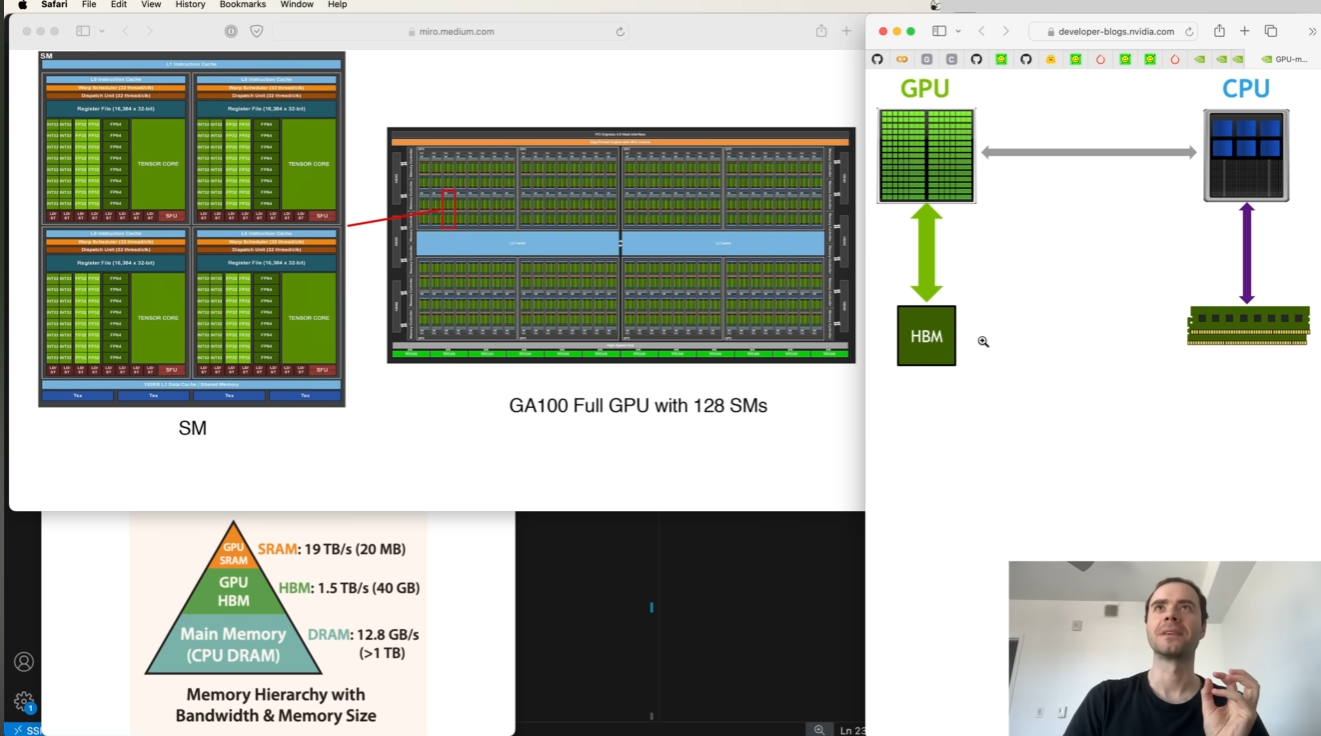

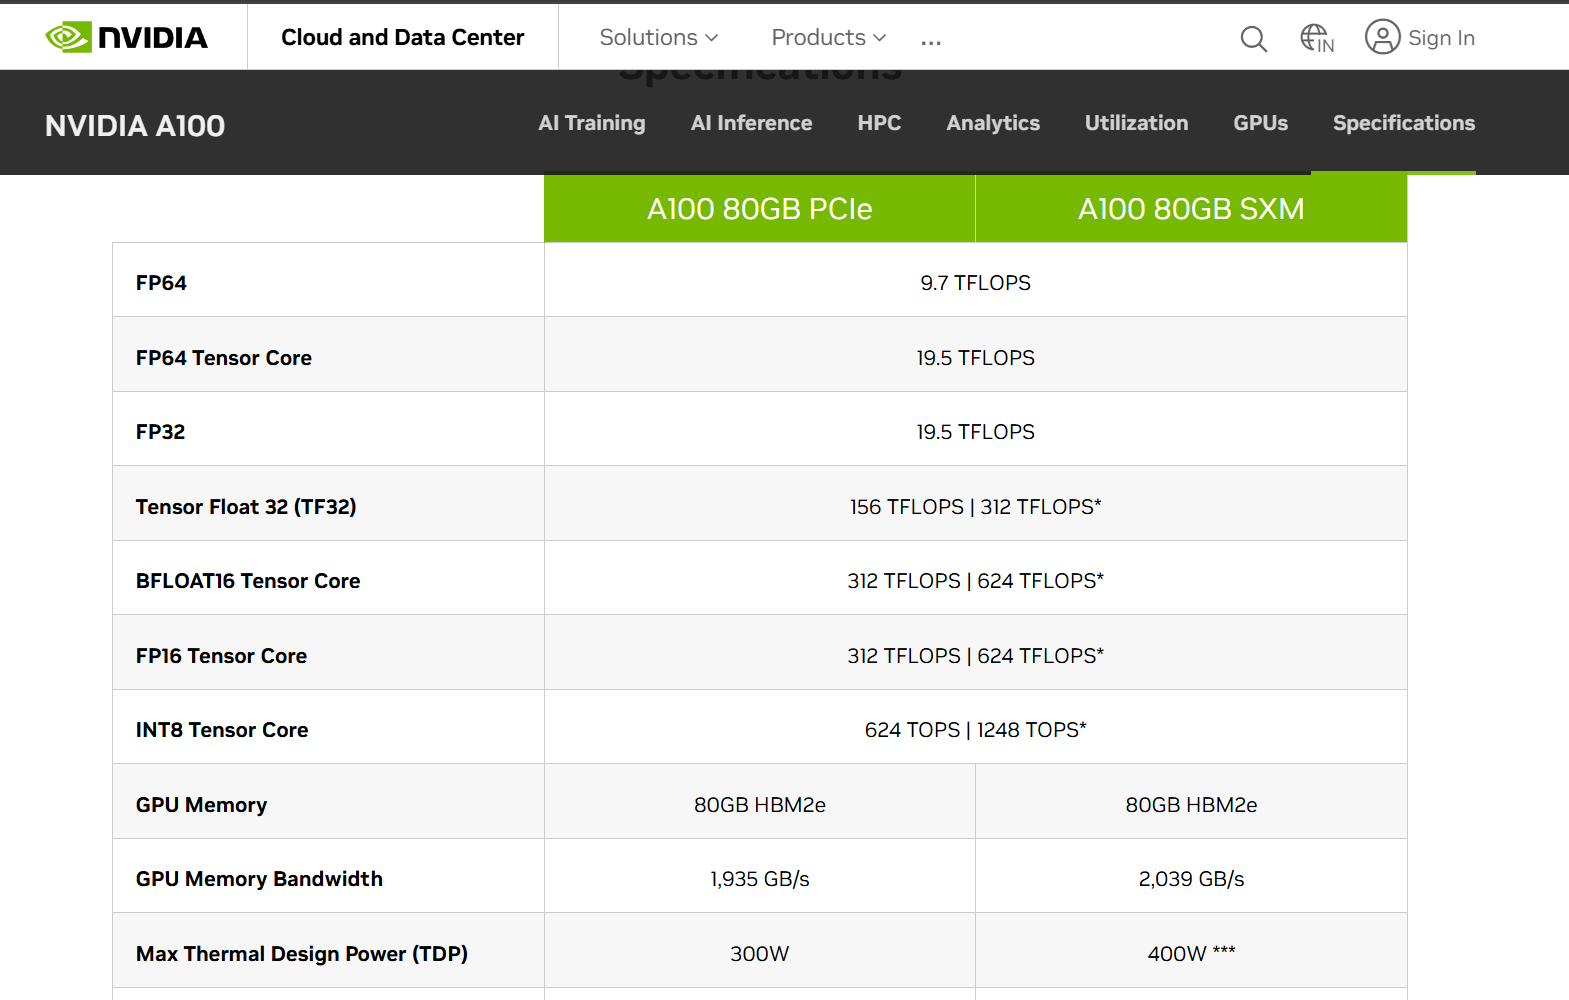

In [ ]:
# Flash Attention - https://arxiv.org/pdf/2205.14135
# These 4 lines in forward pass will be replaced by flash attention -

# att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
# att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
# att = F.softmax(att, dim=-1)
# y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

# It shrinks the pytorch operations matmul, mask, softmax, dropout into a single fused kernel of 
# flash attention. Its a kernel fusion algorithm that torch.compile() cannot find because it requires an 
# algorithmic rewrite of how attention is implemented. 
# According to the paper, its 7.6 times faster than attention despite performing more flops.
# Why - Its mindful of memery hierarchy like whats in high bandwidth(GPU) memory, whats in shared memory, its 
# careful on how to orchestrate the computation so that we have a fewer reads and writes to GPU memory.
# Even though its does more flops, the expensive of part of load and store to GPU memory is avoided.
# The NxN attention matrix is never materialized and never read/written to GPU memory.
# In flash attention, softmax is calculated in a streaming manner so its faster and requires less memory.
# Being aware of memory hierarchy, number of flops dont matter, entire memory access pattern matters, there
# are many optimizations that torch.compile() cannot find.

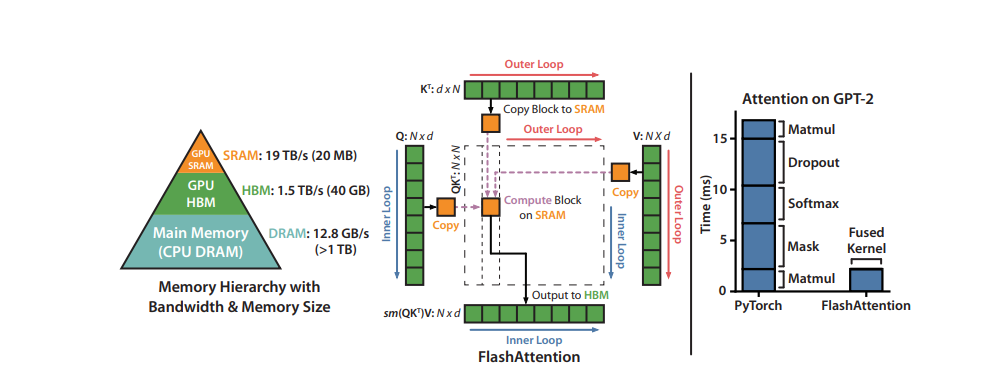

In [ ]:
# Nice and Ugly numbers - 2**X are nice numbers
# Ugly numbers - prime, not even
# Always use nice numbers in code that deals with neural networks or cuda
# Increased vocab_size to 50304 (more flops) from 50257

In [ ]:
# Hyper parameters - Use Adam with betas 0.9, 0.95 and eps 1e-8(default but we mention explicitly)

In [ ]:
# Learning rate - Cosine decay learning schedule with warmup
# From paper - we use cosine decay for learning rate down to 10% of its value, over 260 billion tokens 
# (after 260 billion tokens, training continues at 10% of the original learning rate). There is a linear 
# LR warmup over the first 375 million tokens.
# In paper, the decay time is less than max steps time but for us its exactly equal.
# What learning rate schedule we use is upto us, this is research area. Cosine one has been popularized by GPT

In [ ]:
# Batch size increase -
# From paper - We also gradually increase the batch size linearly from a small value (32k tokens) to the 
# full value over the first 4-12 billion tokens of training, depending on the model size.
# Ignoring this as for every example we put through the network, gradients are very highly correlated, look
# roughly the same and we are not getting any benefit from increasing batch size.
# Later after the training, the examples will be very different and gradients will be less correlated and 
# we will get more benefit from increasing batch size

# From paper -
# Data are sampled without replacement during training (until an epoch boundary is reached) to minimize 
# overfitting.
# Our dataloader iterates over chunks of data. They dont become eligible to be drawn again until the 
# the next epoch.

# Weight Decay - Regularization technique to avoid overfitting.
# From paper -
# All models use weight decay of 0.1 to provide a small amount of regularization
# Used configure_optimizers() function -
# weight_decay parameter gets passed into optim_groups which eventually passes into AdamW optimizer
# weight_decay paramter by default is 0.01 in AdamW optimizer, we are changing it to 0.1 as per paper.
# We split up params into two groups - params with weight decay and params without weight decay.
# Its not common to weight decay biases and any 1 dimensional tensors like layernorm, scales and biases.
# We mostly weight decay the weights used in matrix multplication and embeddings.
# Why decay weights? - It is a regularization technique. When you pull down all the weights, you force
# optimization to use more of the weights and dont allow one 1 weight individually to be way too large.
# Kind of forcing the network to distribute work across all channels.
# Using fused in AdamW optimizer - Instead of iterating in a for loop over all params and updating them 
# which launches a lot of kernels, so fused means that all of them are fused into a single kernel, gets rid
# of a lot of overheads so its basically a kernel fusion for AdamW update instead of iterating over tensors

In [ ]:
# To have a faithful representation of all the hyperparameters, we need to use a batch size of 0.5M tokens
# In our context, every single one of our rows is 1024 tokens, so 0.5e6 / 1024 ≈ 488 rows per batch.
# Since we have GPU limits on batch size, we can accumulate gradients over multiple batches and then do 
# a single optimizer step.
# Gradient Accumulation -
# It allows us to simulate in a serial way any arbitary batch size that we set.
# To do a batch size of 0.5M tokens, we just have to run longer and we have to process multiple sequences and
# add up gradients from them to simulate a batch size of 0.5M tokens.

# Now B becomes a micro batch size, still we have BxT indices that go into the transformer and do forward
# and backward pass, but we wont perform an update. Those gradients are going to plus equal on parameter
# gradients(they all will add up). So we do forward and backward "grad_accum_steps" number of times and
# then a single update once that is accumulated.
# So B times T is the number of tokens per forward/backward pass, for 1660ti - 1x1024 = 1024 tokens
# grad_accum_steps = 2^19 / (1 * 1024) = 512